In [18]:
from typing import TypedDict, Literal
import uuid

from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.constants import START, END
from langgraph.checkpoint.memory import MemorySaver

In [19]:
class State(TypedDict):
    notification_content: str
    decision: str
    final_result: str

In [20]:
def prepare_notification(state: State) -> State:
    return {"notification_content": "Customer order #4567 has been shipped."}

In [21]:
def approval_step(state: State) -> Command[Literal["send", "do_not_send"]]:
    response = interrupt({
        "question": "Do you want to send the following notification?",
        "content": state["notification_content"]
    })

    if response == "approve":
        return Command(goto="send", update={"decision": "approved"})
    else:
        return Command(goto="do_not_send", update={"decision": "rejected"})

In [22]:
def send_notification(state: State) -> State:
    # print("Notification sent to customer.")
    state["final_result"] = "Notification sent to customer."
    return state

In [23]:
def skip_notification(state: State) -> State:
    # print("Notification was not sent.")
    state["final_result"] = "Notification was not sent."
    return state

In [24]:
builder = StateGraph(State)
builder.add_node("prepare_notification", prepare_notification)
builder.add_node("approval_step", approval_step)
builder.add_node("send", send_notification)
builder.add_node("do_not_send", skip_notification)

builder.set_entry_point("prepare_notification")
builder.add_edge("prepare_notification", "approval_step")
builder.add_edge("send", END)
builder.add_edge("do_not_send", END)
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

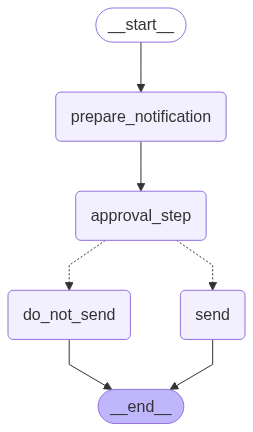

In [25]:
# Visualtize the graph

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)

print(result["__interrupt__"])

[Interrupt(value={'question': 'Do you want to send the following notification?', 'content': 'Customer order #4567 has been shipped.'}, resumable=True, ns=['approval_step:3953c77f-e977-bf1d-2d39-5ae553563340'])]


In [27]:
final_result = graph.invoke(Command(resume="approve"), config=config)
print(final_result)

{'notification_content': 'Customer order #4567 has been shipped.', 'decision': 'approved', 'final_result': 'Notification sent to customer.'}
